In [4]:
#librerias
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict, deque

In [14]:

# ==============================================================  
# Parámetros generales  
# ==============================================================  
CSV_GAME = "../../../data/inputs/csv/game.csv"
CSV_LINE = "../../../data/inputs/csv/line_score.csv"
RANDOM_STATE = 42
EWMA_SPAN = 8
ELO_K = 20
INITIAL_ELO = 1500
HH_WINDOW = 10
DECAY_FACTOR = 0.98

# ==============================================================  
# 1. Carga de datos  
# ==============================================================  
games = pd.read_csv(CSV_GAME)
line_score = pd.read_csv(CSV_LINE)

games['game_date'] = pd.to_datetime(games['game_date'], errors='coerce')


In [15]:

# ============================================
# ELIMINAR 2020 AUTOMÁTICAMENTE
# ============================================
games = games[games['game_date'] >= pd.Timestamp("2021-01-01")].reset_index(drop=True)

games = games.sort_values('game_date').reset_index(drop=True)
games['game_id'] = games.index
games['home_win'] = (games['pts_home'] > games['pts_away']).astype(int)


Eliminamos el 2020 del analisis pues es un año en que debido a las medidas sanitarias derivadas del covid_19, entendemos que pudo producir alteraciones anormales sobre las estadisticas y los resultados.

In [16]:
# ==============================================================  
# 2. Cálculo de ELO  
# ==============================================================  
teams = pd.unique(games[['team_id_home', 'team_id_away']].values.ravel())
elo = {t: INITIAL_ELO for t in teams}
elo_history = []

for _, row in games.iterrows():
    h, a = row['team_id_home'], row['team_id_away']
    he, ae = elo[h], elo[a]
    elo_history.append((he, ae))
    exp_h = 1.0 / (1.0 + 10 ** ((ae - he) / 400.0))
    actual_h = 1.0 if row['pts_home'] > row['pts_away'] else 0.0
    elo[h] += ELO_K * (actual_h - exp_h)
    elo[a] += ELO_K * ((1 - actual_h) - (1 - exp_h))

games['elo_home'] = [e[0] for e in elo_history]
games['elo_away'] = [e[1] for e in elo_history]
games['elo_diff'] = games['elo_home'] - games['elo_away']


In [17]:
# ==============================================================  
# 3. Procesamiento de line_score  
# ==============================================================  
try:
    pts_cols_home = [c for c in line_score.columns if c.startswith('pts_qrt') and c.endswith('_home')]
    pts_cols_away = [c for c in line_score.columns if c.startswith('pts_qrt') and c.endswith('_away')]
    if pts_cols_home and pts_cols_away:
        line_score['home_total_pts'] = line_score[pts_cols_home].sum(axis=1)
        line_score['away_total_pts'] = line_score[pts_cols_away].sum(axis=1)
        line_score['diff_pts_line'] = line_score['home_total_pts'] - line_score['away_total_pts']
    else:
        line_score['diff_pts_line'] = 0
    games = games.merge(line_score[['game_id', 'diff_pts_line']], on='game_id', how='left')
except Exception as e:
    print("Advertencia: no se pudo usar correctamente line_score:", e)
    games['diff_pts_line'] = 0

In [18]:
# ==============================================================  
# 4. Cálculo de EWMA y streaks  
# ==============================================================  
home_cols = ['game_id', 'game_date', 'team_id_home', 'pts_home', 'fgm_home', 'fga_home',
             'fg3m_home', 'fg3a_home', 'ftm_home', 'fta_home', 'reb_home', 'ast_home']
away_cols = ['game_id', 'game_date', 'team_id_away', 'pts_away', 'fgm_away', 'fga_away',
             'fg3m_away', 'fg3a_away', 'ftm_away', 'fta_away', 'reb_away', 'ast_away']

home_df = games[home_cols].copy().rename(columns={
    'team_id_home': 'team_id', 'pts_home': 'pts', 'fgm_home': 'fgm', 'fga_home': 'fga',
    'fg3m_home': 'fg3m', 'fg3a_home': 'fg3a', 'ftm_home': 'ftm', 'fta_home': 'fta',
    'reb_home': 'reb', 'ast_home': 'ast'})
home_df['is_home'] = 1

away_df = games[away_cols].copy().rename(columns={
    'team_id_away': 'team_id', 'pts_away': 'pts', 'fgm_away': 'fgm', 'fga_away': 'fga',
    'fg3m_away': 'fg3m', 'fg3a_away': 'fg3a', 'ftm_away': 'ftm', 'fta_away': 'fta',
    'reb_away': 'reb', 'ast_away': 'ast'})
away_df['is_home'] = 0

team_games = pd.concat([home_df, away_df], ignore_index=True).sort_values(
    ['team_id', 'game_date']).reset_index(drop=True)

team_games['win'] = 0
for idx, row in team_games.iterrows():
    if row['is_home'] == 1:
        result = games.loc[games['game_id'] == row['game_id'], 'home_win'].values[0]
    else:
        result = 1 - games.loc[games['game_id'] == row['game_id'], 'home_win'].values[0]
    team_games.at[idx, 'win'] = result

ewma_stats = ['pts', 'fgm', 'fga', 'fg3m', 'fg3a', 'ftm', 'fta', 'reb', 'ast', 'win']
ewma_list = []
for team, grp in team_games.groupby('team_id', sort=False):
    grp = grp.sort_values('game_date').copy()
    grp['streak5'] = grp['win'].rolling(5, min_periods=1).mean().shift(1)
    ewm = grp[ewma_stats].ewm(span=EWMA_SPAN, adjust=False).mean().shift(1)
    ewm.columns = [f'ewm_{c}' for c in ewma_stats]
    out = pd.concat([grp.reset_index(drop=True), ewm.reset_index(drop=True)], axis=1)
    ewma_list.append(out)

team_games_ewm = pd.concat(ewma_list, ignore_index=True)

rename_home = {f'ewm_{s}': f'home_ewm_{s}' for s in ewma_stats}
rename_home['streak5'] = 'home_streak5'
rename_away = {f'ewm_{s}': f'away_ewm_{s}' for s in ewma_stats}
rename_away['streak5'] = 'away_streak5'

home_ewm = team_games_ewm[team_games_ewm['is_home'] == 1][['game_id', 'streak5'] + [f'ewm_{s}' for s in ewma_stats]].rename(columns=rename_home)
away_ewm = team_games_ewm[team_games_ewm['is_home'] == 0][['game_id', 'streak5'] + [f'ewm_{s}' for s in ewma_stats]].rename(columns=rename_away)

games = games.merge(home_ewm, on='game_id', how='left')
games = games.merge(away_ewm, on='game_id', how='left')

In [19]:
# ==============================================================  
# 5. Variables finales  
# ==============================================================  
games['fg_eff_home'] = games['home_ewm_fgm'] / (games['home_ewm_fga'] + 1e-6)
games['fg_eff_away'] = games['away_ewm_fgm'] / (games['away_ewm_fga'] + 1e-6)
games['ft_eff_home'] = games['home_ewm_ftm'] / (games['home_ewm_fta'] + 1e-6)
games['ft_eff_away'] = games['away_ewm_ftm'] / (games['away_ewm_fta'] + 1e-6)

games['streak_diff'] = games['home_streak5'] - games['away_streak5']
games['fg_eff_diff'] = games['fg_eff_home'] - games['fg_eff_away']
games['ft_eff_diff'] = games['ft_eff_home'] - games['ft_eff_away']
games['reb_diff'] = games['home_ewm_reb'] - games['away_ewm_reb']
games['ast_diff'] = games['home_ewm_ast'] - games['away_ewm_ast']

feat_cols = ['elo_diff', 'streak_diff', 'fg_eff_diff', 'ft_eff_diff',
             'reb_diff', 'ast_diff', 'diff_pts_line']

games[feat_cols] = games[feat_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

In [20]:
# ==============================================================  
# 6. Head-to-head y momentum  
# ==============================================================  
hh_data = defaultdict(lambda: deque(maxlen=HH_WINDOW))
hh_feats = []

for _, row in games.iterrows():
    home, away = row['team_id_home'], row['team_id_away']
    hh = hh_data[(home, away)]
    past = list(hh)
    if past:
        hh_win_rate = np.mean(past)
        hh_games = len(past)
    else:
        hh_win_rate = 0.5
        hh_games = 0
    hh_feats.append((hh_win_rate, hh_games))
    hh.append(1 if row['home_win'] == 1 else 0)

games['hh_win_rate'] = [x[0] for x in hh_feats]
games['hh_games'] = [x[1] for x in hh_feats]

games['elo_hh_adj'] = games['elo_diff'] * (1 + (games['hh_win_rate'] - 0.5))
games['momentum_score'] = (
    0.4 * games['streak_diff'] +
    0.3 * games['fg_eff_diff'] +
    0.2 * games['ft_eff_diff'] +
    0.1 * games['reb_diff']
)

games['team_strength'] = 0.5 * games['elo_diff'] + 0.5 * games['momentum_score']

feat_cols.extend(['hh_win_rate', 'hh_games', 'elo_hh_adj',
                  'momentum_score', 'team_strength'])

games[feat_cols] = games[feat_cols].replace([np.inf, -np.inf], np.nan).fillna(0)


In [21]:
# ==============================================================  
# 7. Train / Test  
# ==============================================================  
cut = pd.Timestamp('2023-01-01')

train = games[games['game_date'] < cut].copy()
test  = games[(games['game_date'] >= cut) &
              (games['game_date'] < pd.Timestamp('2024-01-01'))].copy()

X_train = train[feat_cols].values
y_train = train['home_win'].values
X_test  = test[feat_cols].values
y_test  = test['home_win'].values

years_diff = (cut - train['game_date']).dt.days / 365
sample_weight = DECAY_FACTOR ** years_diff
weights = compute_sample_weight(class_weight='balanced', y=y_train)


In [22]:
# ==============================================================  
# 8. Modelos  
# ==============================================================  
xgb = XGBClassifier(
    n_estimators=350,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    eval_metric='logloss'
)

xgb_cal = CalibratedClassifierCV(xgb, cv=3, method='sigmoid')

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=4,
    random_state=RANDOM_STATE
)

lr = LogisticRegression(max_iter=1000, C=0.8, random_state=RANDOM_STATE)

xgb_cal.fit(X_train, y_train, sample_weight=sample_weight)

voting = VotingClassifier(
    estimators=[('xgb', xgb_cal), ('rf', rf), ('lr', lr)],
    voting='soft',
    n_jobs=-1
)

voting.fit(X_train, y_train, sample_weight=sample_weight)


VotingClassifier(estimators=[('xgb',
                              CalibratedClassifierCV(base_estimator=XGBClassifier(base_score=None,
                                                                                  booster=None,
                                                                                  callbacks=None,
                                                                                  colsample_bylevel=None,
                                                                                  colsample_bynode=None,
                                                                                  colsample_bytree=0.9,
                                                                                  device=None,
                                                                                  early_stopping_rounds=None,
                                                                                  enable_categorical=False,
                                          

Threshold optimizado balanceado: 0.58
Accuracy 2023 balanceado: 61.30%
              precision    recall  f1-score   support

   VISITANTE       0.56      0.61      0.58       339
       LOCAL       0.67      0.62      0.64       431

    accuracy                           0.61       770
   macro avg       0.61      0.61      0.61       770
weighted avg       0.62      0.61      0.61       770



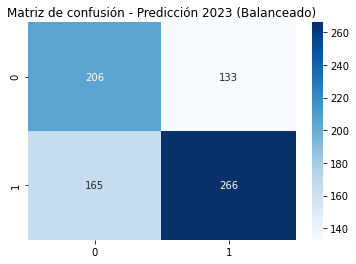

In [23]:
# ==============================================================  
# 9. Predicción y evaluación  
# ==============================================================  
probs = voting.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.3, 0.7, 0.01)

best_thresh = 0.5
best_balance = 999
best_acc = 0

for t in thresholds:
    preds_t = (probs > t).astype(int)
    report = classification_report(
        y_test, preds_t,
        target_names=['VISITANTE', 'LOCAL'],
        output_dict=True
    )
    recall_v = report['VISITANTE']['recall']
    recall_l = report['LOCAL']['recall']
    acc = report['accuracy']
    balance = abs(recall_v - recall_l)
    if balance < best_balance or (balance == best_balance and acc > best_acc):
        best_balance = balance
        best_thresh = t
        best_acc = acc

preds = (probs > best_thresh).astype(int)

print(f"Threshold optimizado balanceado: {best_thresh:.2f}")
acc = accuracy_score(y_test, preds)
print(f"Accuracy 2023 balanceado: {acc*100:.2f}%")
print(classification_report(y_test, preds, target_names=['VISITANTE','LOCAL']))

cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de confusión - Predicción 2023 (Balanceado)")
plt.show()


In [24]:
# ==============================================================  
# 10. Exportación  
# ==============================================================  
test_out = test[['game_id','game_date','team_id_home','team_id_away',
                 'pts_home','pts_away','home_win']].copy()

test_out['prob_local'] = probs
test_out['winner_pred'] = np.where(preds==1,'LOCAL','VISITANTE')
test_out['acierto'] = (preds == test_out['home_win']).astype(int)

test_out.to_csv('predicciones_2023_balanceado.csv', index=False)

print("Archivo CSV generado: predicciones_2023_balanceado.csv")


Archivo CSV generado: predicciones_2023_balanceado.csv
